# 6. Two qubits, and entanglement

Every notebook so far has described one thing at a time. Adding a second qubit
introduces the one feature of quantum mechanics with no classical shadow at all.

The first surprise is bookkeeping. Two classical bits need $2 + 2 = 4$ numbers to
describe separately, or 4 states in total. Two qubits need a $2\times2 = 4$
dimensional space:

$$|\psi\rangle = c_{00}|00\rangle + c_{01}|01\rangle
               + c_{10}|10\rangle + c_{11}|11\rangle .$$

Dimensions **multiply**. Ten qubits need 1024 amplitudes, fifty need more than
$10^{15}$, and that growth is where any hope of quantum advantage comes from.

The second surprise is that most of those states cannot be split back into "a
state for qubit A" and "a state for qubit B" at all.

In [1]:
(define (eye n) (m:generate n n (lambda (i j) (if (= i j) 1 0))))
(define (dagger M) (m:transpose ((m:elementwise conjugate) M)))
(define (ket lst) (m:generate (length lst) 1 (lambda (i j) (list-ref lst i))))
(define (expectation A state) (real-part (ref (* (dagger state) A state) 0 0)))

(define sx (matrix-by-rows (list 0  1) (list 1  0)))
(define sy (matrix-by-rows (list 0 -i) (list +i 0)))
(define sz (matrix-by-rows (list 1  0) (list 0 -1)))
(define gate-H (* (/ 1 (sqrt 2)) (matrix-by-rows (list 1 1) (list 1 -1))))

eye 
dagger 
ket 
expectation 
sx 
sy 
sz 
gate-H 

## 6.1 The tensor product

Combining two systems means taking the **Kronecker product** of their state
spaces. For matrices, $A \otimes B$ replaces each entry $A_{ij}$ by the whole
block $A_{ij}B$. Ordering the basis $|00\rangle, |01\rangle, |10\rangle,
|11\rangle$ -- so index $= 2\times(\text{first qubit}) + (\text{second})$ -- the
index arithmetic is division and remainder.

In [2]:
(define (kron A B)
  (let ((rb (m:num-rows B)) (cb (m:num-cols B)))
    (m:generate (* (m:num-rows A) rb) (* (m:num-cols A) cb)
      (lambda (i j)
        (* (ref A (quotient i rb) (quotient j cb))
           (ref B (remainder i rb) (remainder j cb)))))))

(define ket00 (ket (list 1 0 0 0)))
(define ket11 (ket (list 0 0 0 1)))

;; sigma_z on the first qubit, nothing on the second.
(print-expression (kron sz (eye 2)))

kron 
ket00 
ket11 
(matrix-by-rows (list 1 0 0 0) (list 0 1 0 0) (list 0 0 -1 0) (list 0 0 0 -1))

;No return value.

The same construction says what "a gate on qubit A" means when qubit B is
present: $A \otimes I$. Acting on one half of a pair is always this.

## 6.2 CNOT, and making a Bell state

A two-qubit gate that is not a product of one-qubit gates is needed to build
anything interesting. The standard one is **CNOT**: flip the second qubit if and
only if the first is $|1\rangle$. It is a permutation of the basis, swapping
$|10\rangle \leftrightarrow |11\rangle$.

In [3]:
(define CNOT (matrix-by-rows (list 1 0 0 0)
                             (list 0 1 0 0)
                             (list 0 0 0 1)
                             (list 0 0 1 0)))

;; Hadamard the first qubit, then CNOT. Two gates, starting from |00>.
(define bell (* CNOT (kron gate-H (eye 2)) ket00))
(print-expression bell)

CNOT 
bell 
(matrix-by-rows (list .7071067811865475)
                (list 0)
                (list 0)
                (list .7071067811865475))

;No return value.

$$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt 2}.$$

Classically this looks harmless -- "both bits agree, and which value is 50/50".
The next three sections show it is not that.

## 6.3 Is it a product state?

$|\psi\rangle$ factors as $(a|0\rangle + b|1\rangle)\otimes(c|0\rangle +
d|1\rangle)$ exactly when its coefficients $c_{ij}$, written as a $2\times2$
matrix, have **zero determinant** -- because $c_{ij} = a_i b_j$ makes the matrix
rank one. That gives a one-line test.

In [4]:
(define (coeff-matrix state)
  (m:generate 2 2 (lambda (i j) (ref state (+ (* 2 i) j) 0))))

(define product-state (* (kron gate-H (eye 2)) ket00))   ; |+>|0>, no CNOT

(list 'bell-det    (determinant (coeff-matrix bell))
      'product-det (determinant (coeff-matrix product-state)))

coeff-matrix 
product-state 
(bell-det .4999999999999999 product-det 0)

The product state gives exactly $0$; the Bell state gives $1/2$. So
$|\Phi^+\rangle$ **cannot be written as a state of qubit A times a state of qubit
B**, no matter how the two are chosen. That is the definition of *entangled*. The
pair has a definite state while neither member does.

## 6.4 What Alice sees on her own

To make "neither member has a state" precise, we need density matrices.
$\rho = |\psi\rangle\langle\psi|$ describes the pair, and the **partial trace**
over B sums away everything about B, leaving the best possible description of A
alone.

In [5]:
(define (density state) (* state (dagger state)))
(define (trace M)
  (let loop ((i 0) (s 0)) (if (= i (m:num-rows M)) s (loop (+ i 1) (+ s (ref M i i))))))

;; Trace out qubit B: sum the diagonal blocks.
(define (reduce-to-A rho)
  (m:generate 2 2 (lambda (i k) (+ (ref rho (* 2 i) (* 2 k))
                                   (ref rho (+ (* 2 i) 1) (+ (* 2 k) 1))))))

(print-expression (reduce-to-A (density bell)))

density 
trace 
reduce-to-A 
(matrix-by-rows (list .4999999999999999 0) (list 0 .4999999999999999))

;No return value.

$\rho_A = \tfrac12 I$: the **maximally mixed** state. Alice's qubit is not in
*any* superposition -- it is a coin flip. Her Bloch vector from notebook 5 has
length zero, sitting at the centre of the sphere rather than on its surface.

Two numbers make this quantitative. **Purity** $\mathrm{Tr}(\rho_A^2)$ is 1 for a
pure state and $1/2$ for a maximally mixed qubit. **Entanglement entropy**
$S = -\mathrm{Tr}(\rho_A \ln \rho_A)$ is 0 for a product state and $\ln 2$ for a
maximally entangled pair -- exactly one bit's worth of missing information.

In [6]:
(define (entropy-2x2 rho)
  (let* ((tr   (real-part (+ (ref rho 0 0) (ref rho 1 1))))
         (det  (real-part (- (* (ref rho 0 0) (ref rho 1 1))
                             (* (ref rho 0 1) (ref rho 1 0)))))
         (disc (sqrt (max 0. (- (square tr) (* 4 det)))))
         (plogp (lambda (l) (if (< l 1e-12) 0. (* -1 l (log l))))))
    (+ (plogp (/ (+ tr disc) 2))            ; the two eigenvalues
       (plogp (/ (- tr disc) 2)))))

(define (report name state)
  (let ((r (reduce-to-A (density state))))
    (list name 'purity (real-part (trace (* r r))) 'entropy (entropy-2x2 r))))

(list (report 'bell bell)
      (report 'product product-state)
      'ln2 (log 2.))

entropy-2x2 
report 
#|
((bell purity .4999999999999998 entropy .6931471805599454)
 (product purity .9999999999999996 entropy 2.220446049250313e-16)
 ln2
 .6931471805599453)
|#

Purity $1/2$ and entropy $\ln 2$ for the Bell state; purity $1$ and entropy $0$
for the product state. **The whole is pure while its parts are not** -- there is
information in the pair that is in neither member. Classical probability has no
room for that: a joint distribution always has well-defined marginals that
reconstruct it.

## 6.5 Correlations

Alice and Bob each measure spin along some direction. Take both directions in the
$x$-$z$ plane, at angles $\theta$ from the $z$ axis, so the observable is
$\hat n(\theta)\cdot\vec\sigma = \sin\theta\,\sigma_x + \cos\theta\,\sigma_z$,
with outcomes $\pm 1$. The correlation is the expectation of the product.

For comparison, bring in a third state: the **classically correlated mixture**
$\rho_{\text{mix}} = \tfrac12\big(|00\rangle\langle00| +
|11\rangle\langle11|\big)$. This is a coin flip deciding whether both qubits are
$0$ or both are $1$ -- exactly the naive story people tell about the Bell state,
with nothing quantum in it.

In [7]:
(define (spin-dir theta) (+ (* (sin theta) sx) (* (cos theta) sz)))

;; Works for any density matrix, pure or mixed.
(define (correlation rho ta tb)
  (real-part (trace (* rho (kron (spin-dir ta) (spin-dir tb))))))

(define rho-bell (density bell))
(define rho-mix  (* 1/2 (+ (density ket00) (density ket11))))

(map (lambda (tb) (list 'angle-b tb
                        'bell (correlation rho-bell 0. tb)
                        'mixture (correlation rho-mix 0. tb)
                        'cos-of-angle (cos tb)))
     (list 0. 1. 2.))

spin-dir 
correlation 
rho-bell 
rho-mix 
#|
((angle-b 0. bell .9999999999999998 mixture 1. cos-of-angle 1.)
 (angle-b 1.
          bell
          .5403023058681397
          mixture
          .5403023058681398
          cos-of-angle
          .5403023058681398)
 (angle-b 2.
          bell
          -.4161468365471423
          mixture
          -.4161468365471424
          cos-of-angle
          -.4161468365471424))
|#

Both give $\cos\theta$. **The classical mixture reproduces the Bell state's
correlations exactly** for this family of measurements -- at $\theta = 0$ the
outcomes always agree, and the agreement falls off as the cosine in both cases.

So no single pair of measurement settings can distinguish entanglement from
ordinary correlation. This is why the question stayed philosophical until 1964.

## 6.6 The CHSH inequality

Bell's insight was to combine **four** settings. Alice picks $a$ or $a'$, Bob
picks $b$ or $b'$, and one forms

$$S = E(a,b) - E(a,b') + E(a',b) + E(a',b') .$$

If each qubit carries a definite pre-existing answer for every direction, and
Alice's answer does not depend on Bob's choice, then $|S| \le 2$. The argument is
elementary: with outcomes $\pm1$, the combination
$ab - ab' + a'b + a'b' = a(b-b') + a'(b+b')$ has one bracket zero and the other
$\pm2$.

Quantum mechanics is not bound by that, because there are no pre-existing answers
to have. With the settings $a = 0,\ b = \theta,\ a' = 2\theta,\ b' = 3\theta$:

In [8]:
(define (chsh rho theta)
  (+ (- (correlation rho 0. theta) (correlation rho 0. (* 3 theta)))
     (correlation rho (* 2 theta) theta)
     (correlation rho (* 2 theta) (* 3 theta))))

(list 'bell-at-45-deg (chsh rho-bell (/ pi 4.))
      'tsirelson (* 2 (sqrt 2.))
      'mixture-at-45-deg (chsh rho-mix (/ pi 4.))
      'mixture-max-over-all-angles
      (apply max (map (lambda (k) (abs (chsh rho-mix (* k .005)))) (iota 640))))

chsh 
#|
(bell-at-45-deg 2.82842712474619
                tsirelson
                2.8284271247461903
                mixture-at-45-deg
                1.414213562373095
                mixture-max-over-all-angles
                2.)
|#

$S = 2\sqrt2 \approx 2.828$ for the Bell state, comfortably past 2. The classical
mixture, scanned over every angle, reaches $2.000$ and not a thousandth more.

$2\sqrt2$ is **Tsirelson's bound**, the most any quantum state can achieve. Nature
breaks the classical limit, but not by as much as raw no-signalling would permit.

In [9]:
(define (plot-data win xs ys)
  (let loop ((xs xs) (ys ys))
    (if (and (pair? (cdr xs)) (pair? (cdr ys)))
        (begin (plot-line win (car xs) (car ys) (cadr xs) (cadr ys))
               (loop (cdr xs) (cdr ys))))))

plot-data 

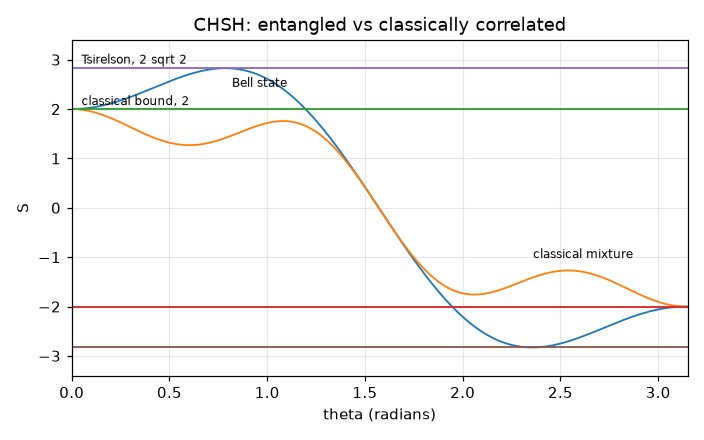

In [10]:
%%plot --title "CHSH: entangled vs classically correlated" --xlabel "theta (radians)" --ylabel "S" --grid
(define win (frame 0. 3.15 -3.4 3.4))
(define angles (iota 316 0. .01))
(plot-data win angles (map (lambda (th) (chsh rho-bell th)) angles))
(plot-data win angles (map (lambda (th) (chsh rho-mix  th)) angles))
(plot-line win 0. 2. 3.15 2.)                   ; classical bound
(plot-line win 0. -2. 3.15 -2.)
(plot-line win 0. 2.8284 3.15 2.8284)           ; Tsirelson bound
(plot-line win 0. -2.8284 3.15 -2.8284)
(graphics-draw-text win .05 2.92 "Tsirelson, 2 sqrt 2")
(graphics-draw-text win .05 2.08 "classical bound, 2")
(graphics-draw-text win .82 2.45 "Bell state")
(graphics-draw-text win 2.36 -1.02 "classical mixture")

The Bell-state curve touches Tsirelson's bound at $\theta = \pi/4$ and again,
negatively, at $3\pi/4$. The classical mixture stays inside $\pm2$ everywhere,
grazing it but never crossing.

This is not a matter of interpretation. Experiments have measured that curve --
Aspect in 1982, and loophole-free versions from 2015 -- and it is the quantum one.
The 2022 Nobel Prize in Physics went to Aspect, Clauser and Zeilinger for doing
it.

**Nothing here allows sending a signal.** Alice's own statistics come from
$\rho_A = \tfrac12 I$ whatever Bob does, so her outcomes are 50/50 regardless of
his choice of axis. The correlation only appears when the two records are brought
together and compared, and that comparison travels no faster than a phone call.

## What to carry forward

- Composite systems take the **tensor product**: dimension multiplies.
- Most joint states do not factor. The Bell state is entangled, and
  $\det(c_{ij}) \neq 0$ proves it in one line.
- An entangled pair is pure while each member is maximally mixed: entropy
  $\ln 2$.
- Entanglement is not just strong correlation -- CHSH separates them, $2\sqrt2$
  against $2$.
- Correlations are non-local; signalling is not.

Next: [two quantum algorithms](07-quantum-algorithms.ipynb), where superposition
and interference are put to work.